# pop-cosmos: Bayesian SED fitting

This notebook will demonstrate how to use the `pop_cosmos`, `speculator`, and `affine` packages to .

We'll start by importing some dependencies, and the relevant submodules from `pop_cosmos`. Before you run this notebook, you should follow the installation instructions in the `README.md`

In [1]:
#Import dependencies and pop_cosmos
import numpy as np
import matplotlib.pyplot as plt
import torch
import pickle
import h5py
from corner import corner
from tqdm import tqdm
from astropy.cosmology import Planck18

from affine import sample, sample_batch

from speculator import PhotulatorModelStack

from pop_cosmos.constants import COSMOS_FILTERS_LATEX, COSMOS_FILTERS, ERRORFLOOR_LEISTEDT23
from pop_cosmos.catalogue import CatalogueGenerator
from pop_cosmos.utils import compute_derived_quantities, compute_mass_remaining

# Set fontsizes
plt.rcParams['font.size'] = 15

/opt/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Load the trained model(s)

In the next cell we will load a pickled `pop_cosmos.catalogue.CatalogueGenerator` object that contains the Thorp et al. (2025) version of the `pop-cosmos` model. If you're using `torch >= 2.4`, the unpickling step here (and in cell `[4]`) may run into difficulties when the `speculator` models are loaded. Using `weights_only=False` will partially resolve this, but you may need to use two further lines to tell `torch` that it's okay to unpickle the `speculator` models:
```python
torch.serialization.add_safe_globals([speculator.speculator.Photulator])
torch.serialization.add_safe_globals([torch.nn.modules.container.ParameterList])
```
This is a known [issue](https://github.com/justinalsing/speculator/issues/10) with `speculator`.

In [2]:
#Load model trained in Thorp et al. (2025) on the CPU
catalogue_generator = torch.load("../trained_models/catalogueModelT25.pt", weights_only=False)

And now, we will load in an additional emulator that is needed to correct the stellar masses predicted by the model (which by default are the stellar mass _formed_ by a galaxy over its lifetime) for mass loss (so we will end up with stellar mass _remaining_).

In [3]:
#Load a secondary emulator needed for some derived quantities
mass_remaining_emulator = torch.load("../trained_models/stellar_mass_emulator.pt", map_location="cpu", weights_only=False)
mass_theta_shift, mass_theta_scale = pickle.load(open("../trained_models/stellar_mass_parameter_shift-scale.pkl", "rb"))
mass_theta_shift = torch.from_numpy(mass_theta_shift)
mass_theta_scale = torch.from_numpy(mass_theta_scale)

And in case we want to work with Rubin data, we can load some emulators for those bands too!

In [4]:
#Load some Rubin photometry emulators 
#(not strictly needed as the cosmos ones are packed into the catalogue_generator)
emulator_path = '../trained_models/photulator_models/LSST/'
emulator_name = 'model_4x128_alsing20_lsst_baseline_1_9_{}_cpu.pt'
filter_names = 'ugrizy'
filter_colors = ["#0c71ff", "#49be61", "#c61c00", "#ffc200", "#f341a2", "#5d0000"]
rubin_flux_emulator = PhotulatorModelStack('', [emulator_path + emulator_name.format(f) for f in filter_names])

## Loading a pre-generated mock

We can use a pretrained mock catalog as a source for making an initial guess of the parameters for our SED fits. We'll load this from the HDF5 file on Zenodo: https://doi.org/10.5281/zenodo.17517601

The `mock_catalogue_tutorial.ipynb` will give a more complete overview of how to work with this file if you're curious!

In [5]:
# Open the HDF5 file
filename = "../../pop-cosmos-mock-zenodo/mock_catalog_Ch1_26.h5"  # Change this to your file path
mock = h5py.File(filename, "r")

## Get our photometry

For the purposes of this demo, we will work with a galaxy from COSMOS (Farmer id. 5963). This has 26-band photometry, including some wide and narrow bands.

In [6]:
#Print the COSMOS filter list
print(COSMOS_FILTERS)

['u_megaprime_sagem', 'hsc_g', 'hsc_r', 'hsc_i', 'hsc_z', 'hsc_y', 'uvista_y_cosmos', 'uvista_j_cosmos', 'uvista_h_cosmos', 'uvista_ks_cosmos', 'ia427_cosmos', 'ia464_cosmos', 'ia484_cosmos', 'ia505_cosmos', 'ia527_cosmos', 'ia574_cosmos', 'ia624_cosmos', 'ia679_cosmos', 'ia709_cosmos', 'ia738_cosmos', 'ia767_cosmos', 'ia827_cosmos', 'NB711.SuprimeCam', 'NB816.SuprimeCam', 'irac1_cosmos', 'irac2_cosmos']


In [7]:
#Define our galaxy photometry in these bands
f_obs = np.array([0.1000, 0.1093, 0.1221, 0.1372, 0.2172, 
                  0.2399, 0.3026, 0.3115, 0.3184, 0.3792,
                  0.0811, 0.0696, 0.0922, 0.1258, 0.1034,
                  0.0999, 0.1152, 0.1321, 0.0899, 0.1353,
                  0.1019, 0.1287, 0.1118, 0.1051, 0.4454, 0.3905]) # fluxes in nano maggies
f_err = np.array([0.0021, 0.0014, 0.0018, 0.0019, 0.0030,
                  0.0065, 0.0143, 0.0148, 0.0186, 0.0114,
                  0.0057, 0.0072, 0.0039, 0.0058, 0.0038,
                  0.0066, 0.0045, 0.0073, 0.0054, 0.0063,
                  0.0084, 0.0072, 0.0111, 0.0064, 0.0076, 0.0085])
f_obs = torch.from_numpy(f_obs)
f_err = torch.from_numpy(f_err)

## Set up a likelihood function

Now, we can set up a PyTorch function defining our log likelihood. We'll work with a Gaussian log likelihood to start off with.

In [8]:
def log_like(f_model, f_obs, f_err):
    ll = -0.5*((f_model - f_obs)/f_err)**2.
    return torch.sum(ll, dim=-1) # Summing over the bands

## Making an initial guess of the parameters

We can make a rough initial guess of the best fitting parameters by finding the maximum likelihood model galaxy in the mock catalog. This is the procedure used in the Thorp et al. (2024) paper to initialize things.

If you don't have the mock catalog downloaded, here are some good initial guesses for this galaxy that you can copy into a new cell and use for the next steps:
```python
f_mle = torch.tensor([0.0911, 0.1041, 0.1187, 0.1365, 0.2211,
                      0.2474, 0.2406, 0.2753, 0.3222, 0.3930,
                      0.0934, 0.0921, 0.0985, 0.0985, 0.0966,
                      0.0954, 0.1109, 0.1354, 0.1193, 0.1218,
                      0.1254, 0.1372, 0.1210, 0.1223, 0.4129, 0.4119])
theta_mle = torch.tensor([20.0272, -1.4193,  0.1677,  0.1611,  
                          0.1254, -0.0325, -0.1381, -0.0569, 
                          0.4827,  0.3139,  0.8754, -1.3199,  
                          3.0758, -1.3194, -1.9458,  1.2390])
phi_mle = torch.tensor([[2.0027e+01, -6.4829e-01,  4.2047e-02,  4.0405e-02,
                        3.1430e-02, -8.1468e-03, -3.4613e-02, -1.4256e-02,
                        -1.1717e+00,  1.5425e+00, -1.5675e-01,  8.7139e-01,
                        -1.7348e-01, -6.0602e-01,  4.8099e-01, -8.1860e-01]])[None,...]
```

In [9]:
f_mock = 1e9*torch.from_numpy(mock['fluxes_noiseless'][:]) # convert to maggies

ll = log_like(f_mock, f_obs, f_err)
i_mle = torch.argmax(ll)
ll_mle = ll[i_mle]
f_mle = f_mock[i_mle]
theta_mle = mock['sps_parameters'][i_mle]

# We need to manually transform the first parameter in the theta vector
theta_mle[0] = Planck18.distmod(theta_mle[-1]).value - 2.5*theta_mle[0]
theta_mle = torch.from_numpy(theta_mle)
phi_mle = catalogue_generator.theta2phi(theta_mle[None,:])

print('Maximum likelihood mock galaxy:')
print('flux =', f_mle)
print('log likelihood =', ll_mle)
print('sps parameters =', theta_mle)
print('transformed parameters =', phi_mle)

Maximum likelihood mock galaxy:
flux = tensor([0.0911, 0.1041, 0.1187, 0.1365, 0.2211, 0.2474, 0.2406, 0.2753, 0.3222,
        0.3930, 0.0934, 0.0921, 0.0985, 0.0985, 0.0966, 0.0954, 0.1109, 0.1354,
        0.1193, 0.1218, 0.1254, 0.1372, 0.1210, 0.1223, 0.4129, 0.4119])
log likelihood = tensor(-92.3626, dtype=torch.float64)
sps parameters = tensor([20.0272, -1.4193,  0.1677,  0.1611,  0.1254, -0.0325, -0.1381, -0.0569,
         0.4827,  0.3139,  0.8754, -1.3199,  3.0758, -1.3194, -1.9458,  1.2390])
transformed parameters = tensor([[ 2.0027e+01, -6.4829e-01,  4.2047e-02,  4.0405e-02,  3.1430e-02,
         -8.1468e-03, -3.4613e-02, -1.4256e-02, -1.1717e+00,  1.5425e+00,
         -1.5675e-01,  8.7139e-01, -1.7348e-01, -6.0602e-01,  4.8099e-01,
         -8.1860e-01]])


## Refine the initial guess

Now, we will use the PyTorch Adam optimizer to refine our initial parameter guess to a proper MAP estimate. To do this, we will need to define our log posterior function first. This will operate on something we'll call $\mathbf{\phi}$, which is a rescaled vector of parameters that will be easier for the sampler and optimizer to deal with. The `CatalogueGenerator` object provides some functions for transforming from the SPS parameters, $\mathbf{\theta}$, and the rescaled $\mathbf{\phi}$.

In [10]:
# Define the log posterior

def log_prob(phi, f_obs, f_err):
    # Convert to SPS parameter space
    theta = catalogue_generator.phi2theta(phi)
    # Compute model magnitudes
    m_model = catalogue_generator.flux_emulator.magnitudes(
        catalogue_generator.emulator_parameter_transform(theta)[:,1:], theta[:,0].unsqueeze(-1) )
    # Compute model fluxes
    f_model = 10**(0.4*(22.5 - m_model)) # in nano maggies
    
    # Emission line corrections
    
    # Compute the log likelihood and log prior
    ll = log_like(f_model, f_obs, f_err)
    lp = catalogue_generator.population_model.log_prob(phi).flatten()
    
    return ll + lp

In [11]:
# Define a Parameter object to optimize
phi_map = torch.nn.Parameter(phi_mle)

# Define a lambda function to optimize
log_prob_func = lambda phi: log_prob(phi, f_obs, f_err) 

optimizer = torch.optim.Adam([phi_map], lr=1e-3)

for _ in tqdm(range(200)):
    optimizer.zero_grad()
    loss = -log_prob_func(phi_map)
    loss.backward()
    optimizer.step()
    
phi_map = phi_map[0].detach()
theta_map = catalogue_generator.phi2theta(phi_map)

print('sps parameters =', theta_map)
print('transformed parameters =', phi_map)

100%|█████████████████████████████████████████| 200/200 [01:37<00:00,  2.06it/s]

sps parameters = tensor([20.0415, -1.4102,  0.0971,  0.2060,  0.1623, -0.0314, -0.1683, -0.1221,
         0.4511,  0.3307,  0.8101, -1.6117,  3.2511, -1.4489, -1.7667,  1.2300])
transformed parameters = tensor([ 2.0042e+01, -6.3534e-01,  2.4353e-02,  5.1669e-02,  4.0698e-02,
        -7.8697e-03, -4.2196e-02, -3.0618e-02, -1.2118e+00,  1.6500e+00,
        -2.4030e-01,  7.8950e-01, -4.3473e-02, -7.7067e-01,  6.5706e-01,
        -8.2391e-01])


## Run MCMC

Now we can run our MCMC, using the MAP estimate as an initial guess!

In [12]:
n_params = 16
n_walkers = 256
n_steps = 100

# We need two ensembles of walkers, which we'll start in a tight ball around the MAP estimate
walkers1 = torch.randn(n_walkers, n_params)*0.1 + phi_map
walkers2 = torch.randn(n_walkers, n_params)*0.1 + phi_map

with torch.no_grad():
    mcmc_phi = sample(log_prob_func, n_params, n_walkers, n_steps, walkers1, walkers2, progress=True, save_lp=False)

Sampling:  99%|███████████████████████████████▋| 99/100 [12:19<00:07,  7.47s/it]


In [13]:
# Convert parameters to SPS space and discard first half
mcmc_theta = catalogue_generator.phi2theta(mcmc_phi)[int(n_steps/2):].reshape(-1, 16).detach().numpy()

# Convert first column to mass formed
mcmc_theta[:,0] = (Planck18.distmod(mcmc_theta[:,-1]).value - mcmc_theta[:,0])/2.5

## Plot the posterior

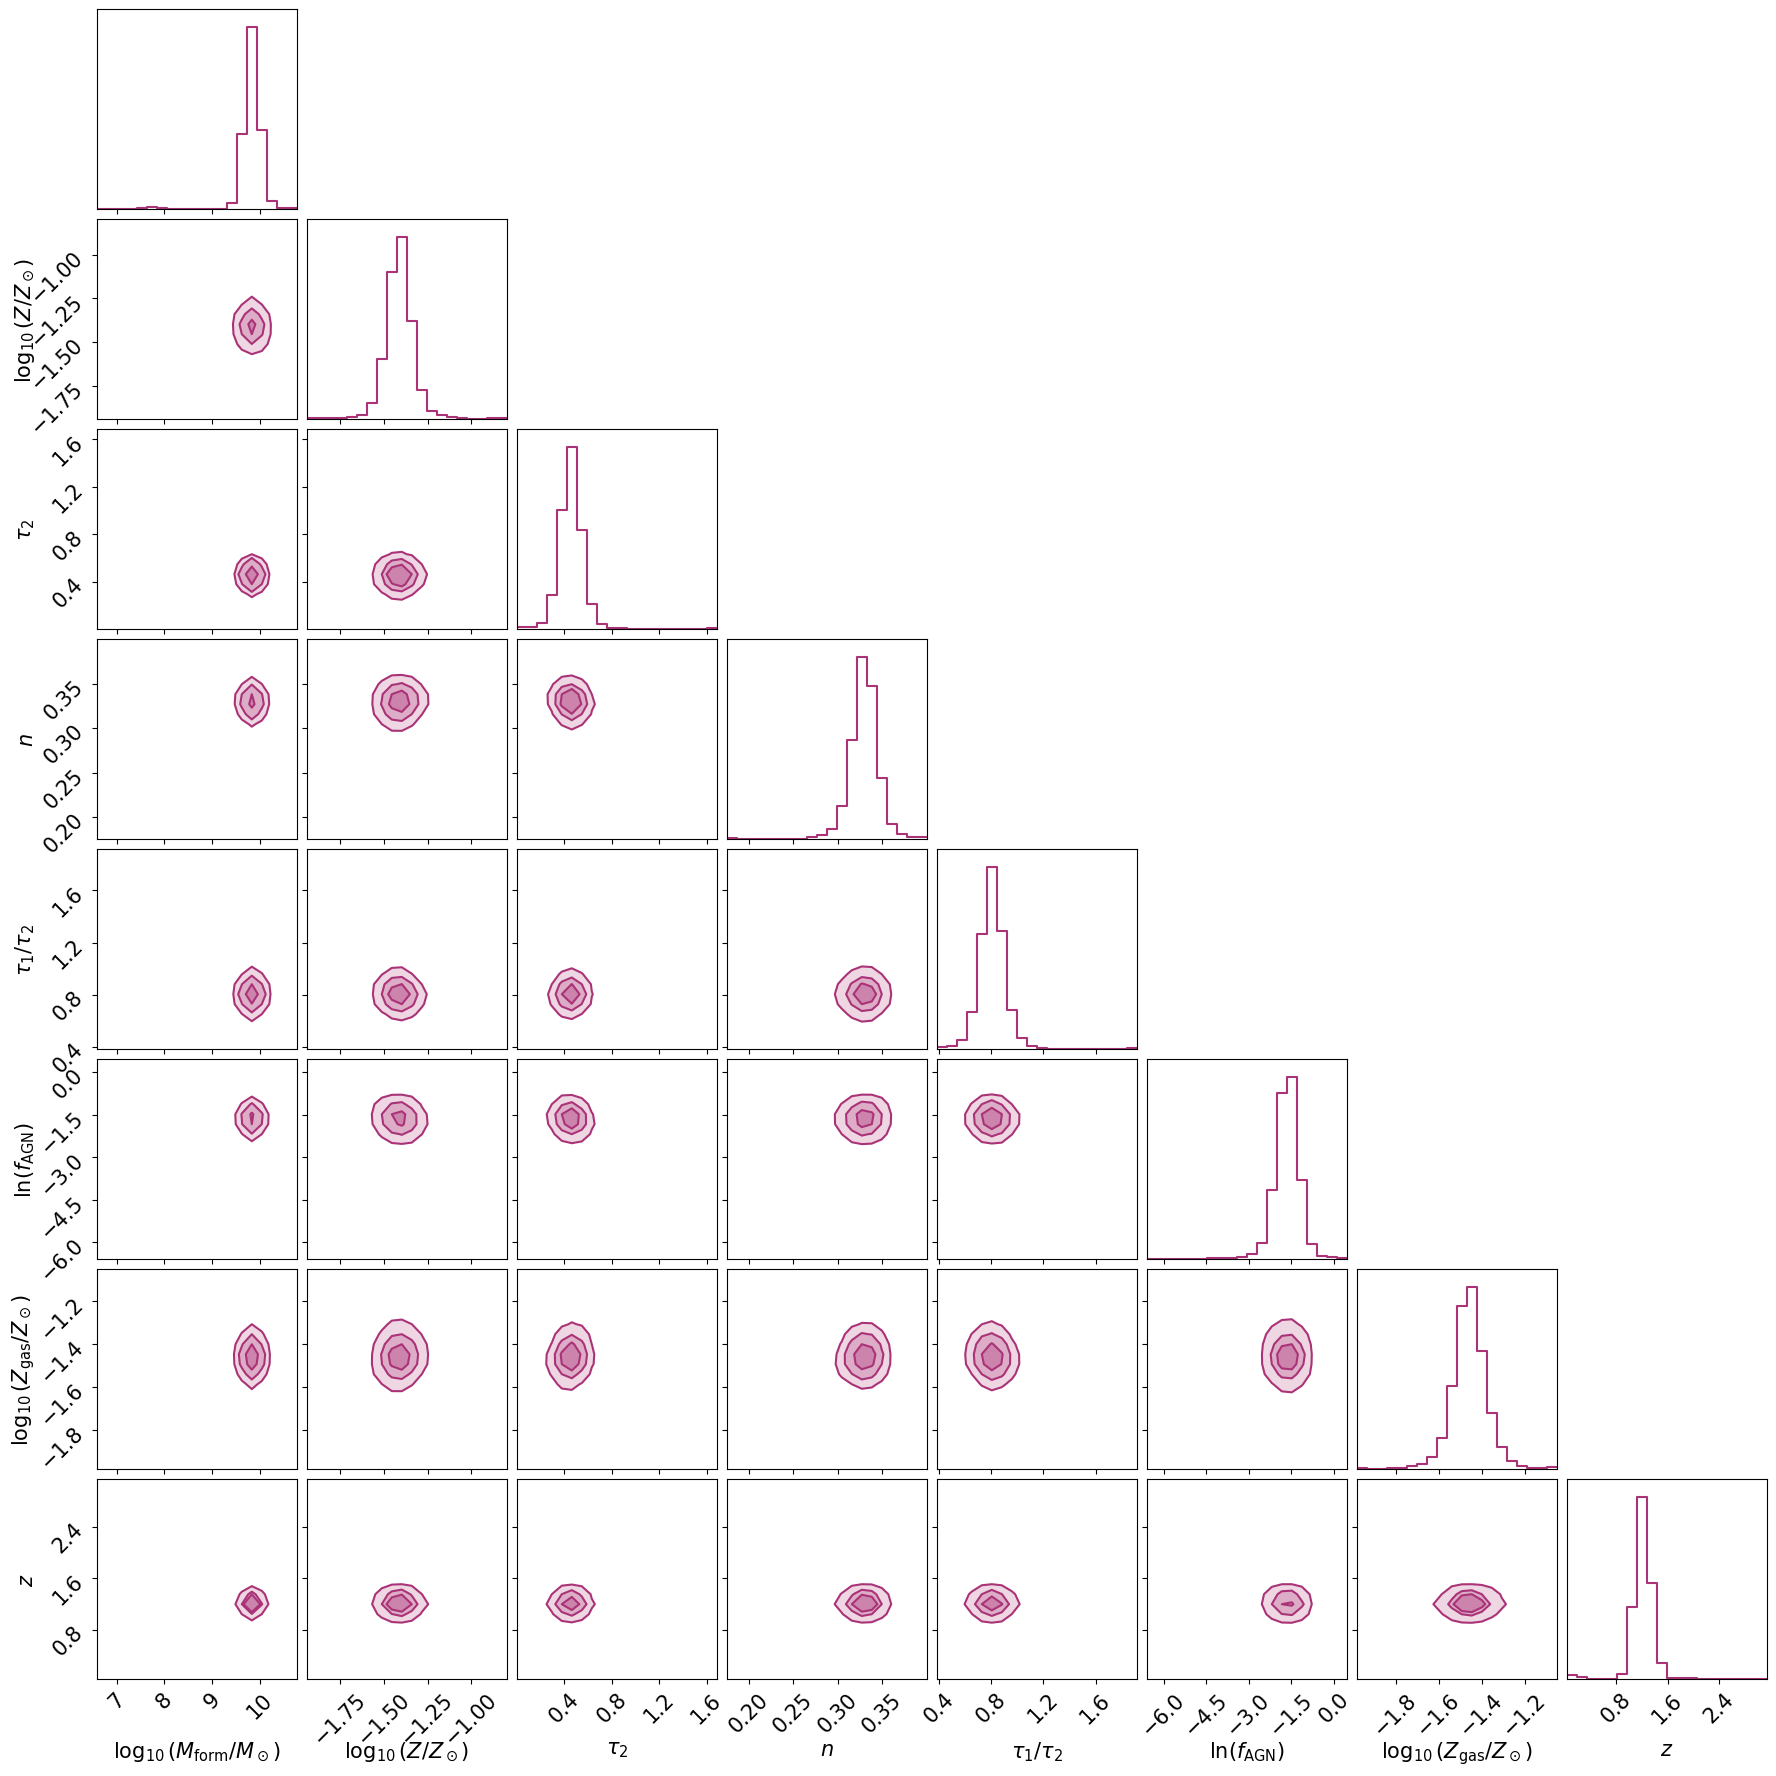

In [14]:
# Make a corner plot of some interesting parameters
# Choose some parameters
cols = [0, 1, 8, 9, 10, 11, 13, 15]
# LaTeX names for these parameters
pnames = [
    '$\\log_{{10}}(M_\\mathrm{{form}}/M_\\odot)$',
    '$\\log_{{10}}(Z/Z_\\odot)$',
    '$\\tau_2$',
    '$n$',
    '$\\tau_1/\\tau_2$',
    '$\\ln(f_\\mathrm{{AGN}})$',
    '$\\log_{{10}}(Z_\\mathrm{{gas}}/Z_\\odot)$',
    '$z$'
]

corner(mcmc_theta[:,cols], labels=pnames, color="#AA3377", smooth=0.75, smooth1d=0.75, plot_density=True, fill_contours=True, plot_datapoints=False)
plt.show()

## Emission line & zero-point corrections

In Thorp et al. (2024), we use a slightly more complicated likelihood function that includes emission line & zero point corrections, based on the form used by Leistedt et al. (2023). Let's try setting that up.

The zero point corrections here are COSMOS-specific, so likely won't be applicable to other surveys. The emission line corrections are more generally applicable (but different surveys will need a different model to be loaded in).

In [15]:
# Student's t log likelihood (based on Leistedt+ and Thorp+)
def log_like(f_model, f_em, f_obs, f_err, alpha_zp, beta_em, gamma_em, y_floor):
    # error floor
    sigma_floor = alpha_zp * y_floor * f_model
    # emission line error contributions
    sigma_em = alpha_zp * torch.sum(gamma_em * (1 + beta_em) * f_em, dim=-1)
    # total squared error term
    s2 = f_err**2. + sigma_em**2. + sigma_floor**2.
    # corrected model flux
    f = alpha_zp * (f_model + torch.sum(beta_em * f_em, dim=-1))
    # scaled Student t with 2 d.o.f
    ll = - 1.5*torch.log10(1. + 0.5*((f_obs - f)**2.)/s2) - 0.5*torch.log10(s2)
    return torch.sum(ll, dim=-1) # Summing over the bands

In [16]:
# Redefine the log posterior
def log_prob(phi, f_obs, f_err):
    # Convert to SPS parameter space
    theta = catalogue_generator.phi2theta(phi)
    # Compute model magnitudes
    m_model = catalogue_generator.flux_emulator.magnitudes(
        catalogue_generator.emulator_parameter_transform(theta)[:,1:], theta[:,0].unsqueeze(-1) )
    # Compute model fluxes
    f_model = 10**(0.4*(22.5 - m_model)) # in nano maggies
    # Emission line corrections
    f_em = catalogue_generator.emission_line_flux_emulator(
        catalogue_generator.emulator_parameter_transform(theta) )
    # Compute the log likelihood and log prior
    ll = log_like(f_model, f_em, f_obs, f_err, 
                  catalogue_generator.zero_points,
                  catalogue_generator.emline_offsets, 
                  torch.exp(catalogue_generator.ln_emline_scatters), 
                  catalogue_generator.error_floor)
    lp = catalogue_generator.population_model.log_prob(phi).flatten()
    return ll + lp

In [17]:
# Add error floor to catalogue generator
catalogue_generator.error_floor = torch.from_numpy(ERRORFLOOR_LEISTEDT23)

# Define a Parameter object to optimize
phi_map = torch.nn.Parameter(phi_mle)

# Define a lambda function to optimize
log_prob_func = lambda phi: log_prob(phi, f_obs, f_err) 

optimizer = torch.optim.Adam([phi_map], lr=1e-3)

for _ in tqdm(range(200)):
    optimizer.zero_grad()
    loss = -log_prob_func(phi_map)
    loss.backward()
    optimizer.step()
    
phi_map = phi_map[0].detach()
theta_map = catalogue_generator.phi2theta(phi_map)

print('sps parameters =', theta_map)
print('transformed parameters =', phi_map)

100%|█████████████████████████████████████████| 200/200 [01:43<00:00,  1.93it/s]

sps parameters = tensor([20.0473, -1.3818,  0.1103,  0.2290,  0.1689, -0.0459, -0.1973, -0.1662,
         0.4532,  0.3380,  0.7847, -1.1233,  3.3849, -1.5570, -1.5901,  1.2246])
transformed parameters = tensor([ 2.0047e+01, -5.9573e-01,  2.7659e-02,  5.7425e-02,  4.2347e-02,
        -1.1500e-02, -4.9472e-02, -4.1684e-02, -1.2091e+00,  1.7028e+00,
        -2.7314e-01,  9.3002e-01,  5.5201e-02, -9.2609e-01,  8.5343e-01,
        -8.2708e-01])


In [18]:
n_params = 16
n_walkers = 256
n_steps = 100

# We need two ensembles of walkers, which we'll start in a tight ball around the MAP estimate
walkers1 = torch.randn(n_walkers, n_params)*0.1 + phi_map
walkers2 = torch.randn(n_walkers, n_params)*0.1 + phi_map

with torch.no_grad():
    mcmc_phi = sample(log_prob_func, n_params, n_walkers, n_steps, walkers1, walkers2, progress=True, save_lp=False)

Sampling:  99%|███████████████████████████████▋| 99/100 [08:43<00:05,  5.29s/it]


In [19]:
# Convert parameters to SPS space and discard first half
mcmc_theta = catalogue_generator.phi2theta(mcmc_phi)[int(n_steps/2):].reshape(-1, 16).detach().numpy()

# Convert first column to mass formed
mcmc_theta[:,0] = (Planck18.distmod(mcmc_theta[:,-1]).value - mcmc_theta[:,0])/2.5

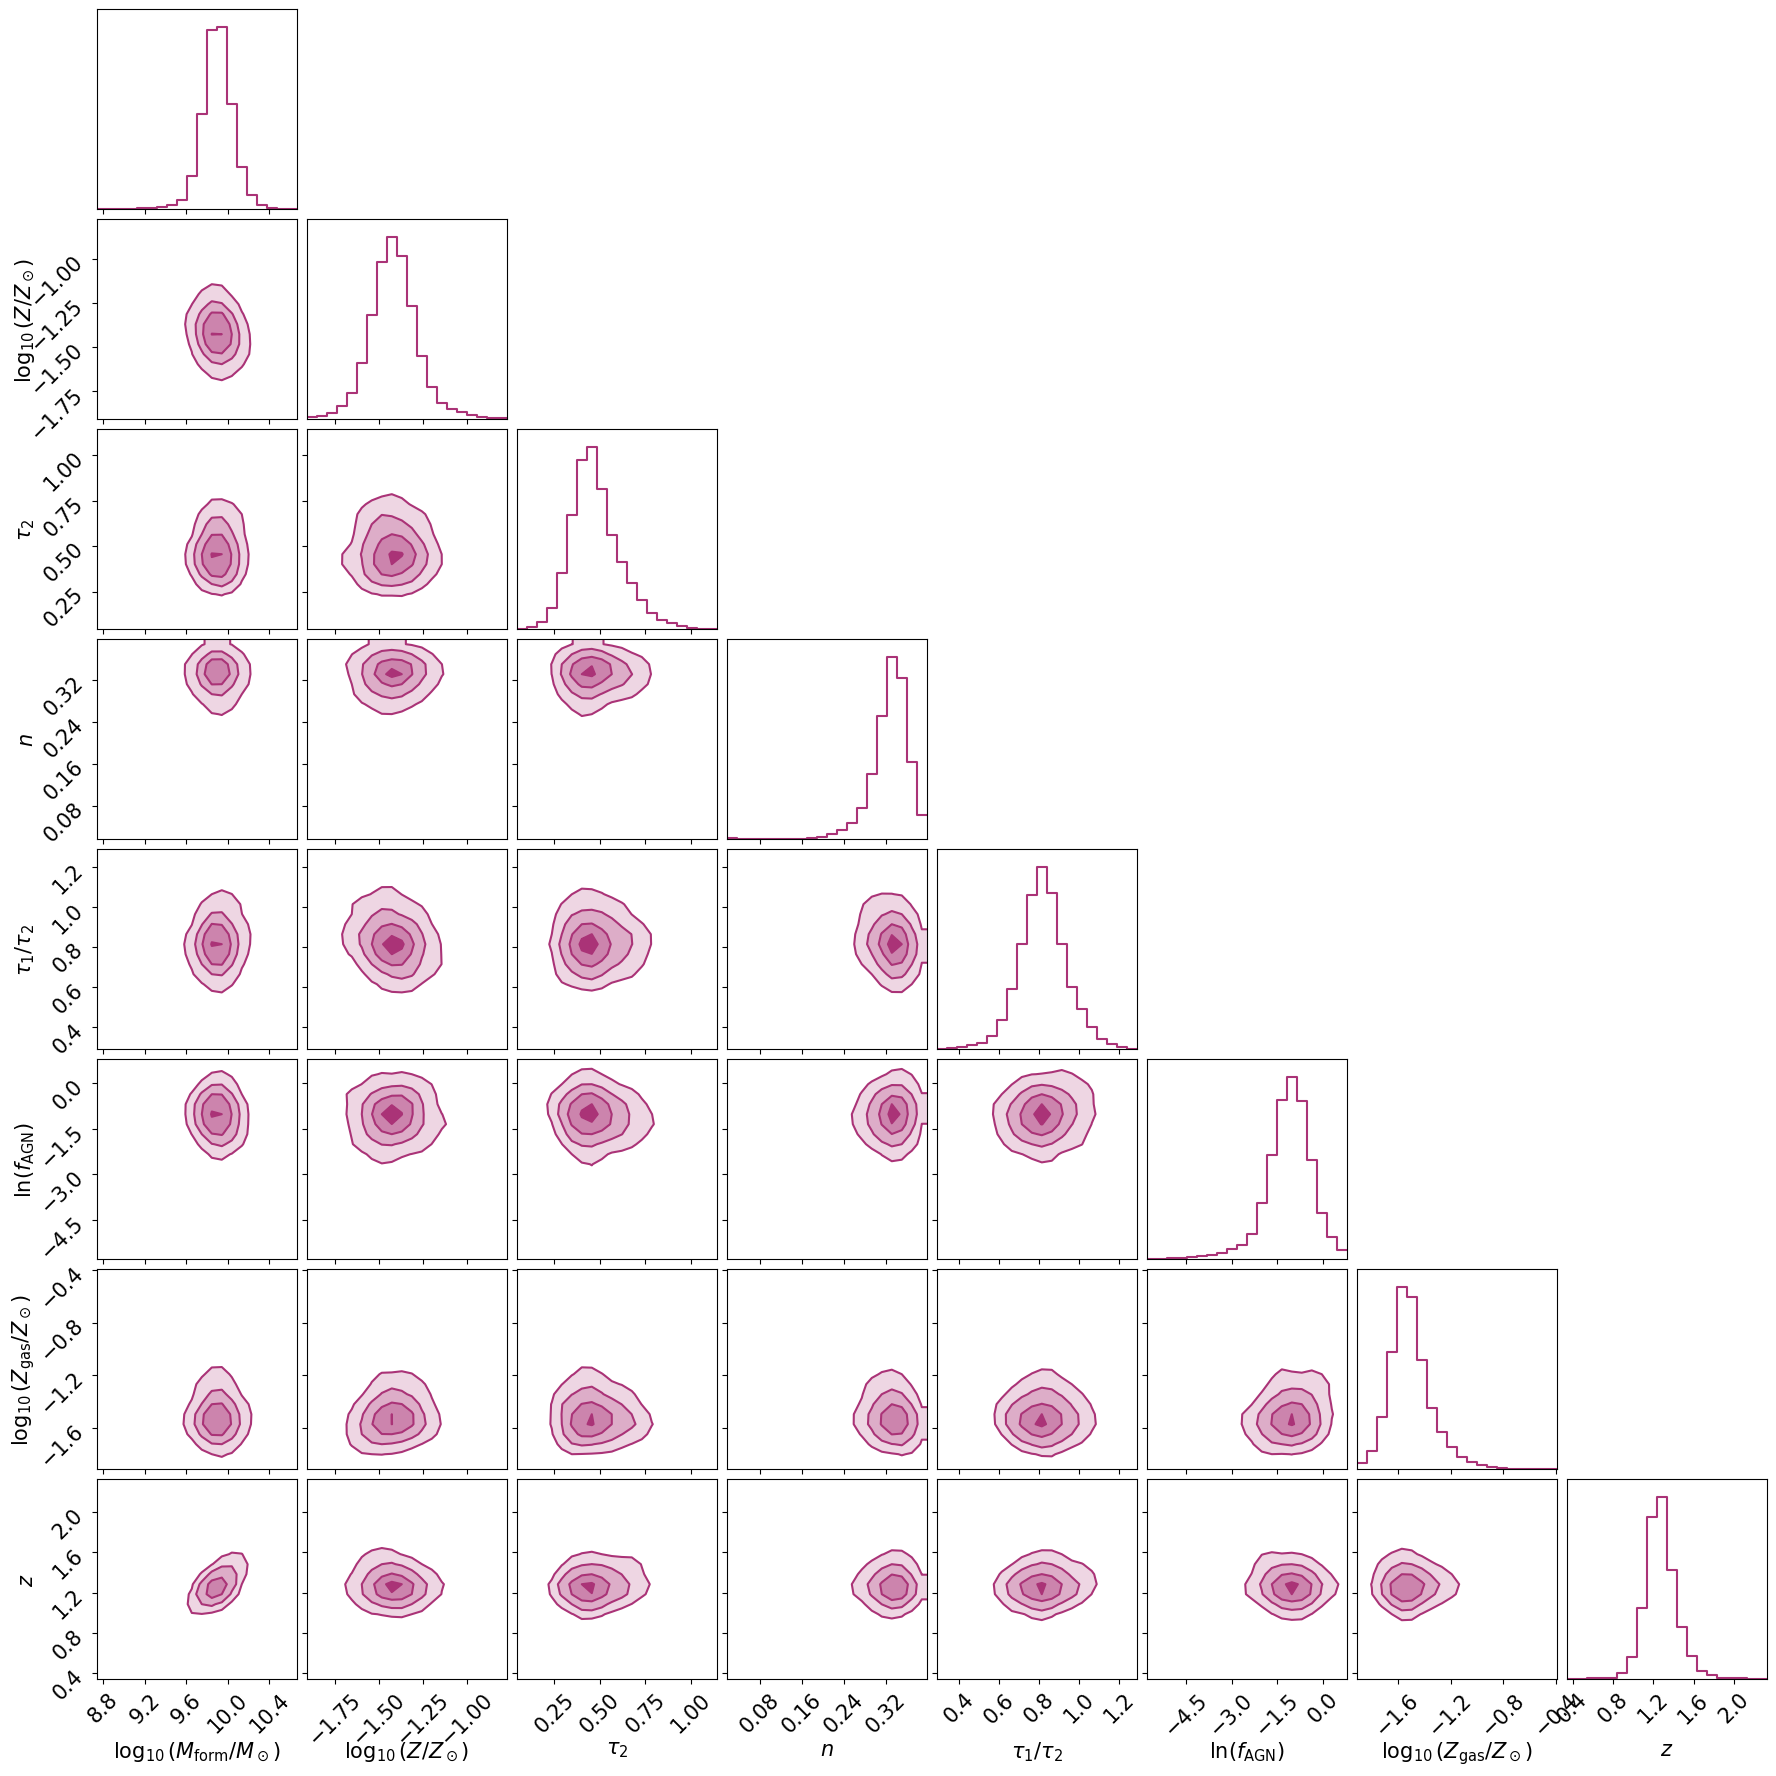

In [20]:
# Make a corner plot of some interesting parameters
# Choose some parameters
cols = [0, 1, 8, 9, 10, 11, 13, 15]
# LaTeX names for these parameters
pnames = [
    '$\\log_{{10}}(M_\\mathrm{{form}}/M_\\odot)$',
    '$\\log_{{10}}(Z/Z_\\odot)$',
    '$\\tau_2$',
    '$n$',
    '$\\tau_1/\\tau_2$',
    '$\\ln(f_\\mathrm{{AGN}})$',
    '$\\log_{{10}}(Z_\\mathrm{{gas}}/Z_\\odot)$',
    '$z$'
]

corner(mcmc_theta[:,cols], labels=pnames, color="#AA3377", smooth=0.75, smooth1d=0.75, plot_density=True, fill_contours=True, plot_datapoints=False)
plt.show()

## Batched evaluation

For greater efficiency, the optimization and MCMC can be batched over multiple galaxies at once, allowing us to benefit from vectorization (this is particularly powerful on GPU; see the appendix of Thorp et al. 2024). In the next cells, let's look at what we need to change to process five galaxies at once.

We'll add four more COSMOS2020 galaxies to our sample for this experiment. These have Farmer id. (5963, 5965, 5969, 5970, 5973).

In [21]:
# Define our galaxy photometry in these bands
f_obs = np.array([[ 1.0005e-01,  1.0925e-01,  1.2213e-01,  1.3723e-01,  2.1722e-01,
                    2.3992e-01,  3.0265e-01,  3.1148e-01,  3.1843e-01,  3.7915e-01,
                    8.1119e-02,  6.9618e-02,  9.2243e-02,  1.2583e-01,  1.0343e-01,
                    9.9944e-02,  1.1517e-01,  1.3214e-01,  8.9883e-02,  1.3530e-01,
                    1.0194e-01,  1.2874e-01,  1.1179e-01,  1.0506e-01,  4.4536e-01, 3.9046e-01],
                  [ 5.8002e-02,  5.8751e-02,  6.2143e-02,  5.8676e-02,  8.2178e-02,
                    6.8963e-02,  7.3363e-02,  7.9841e-02,  8.1395e-02,  8.0448e-02,
                    5.8725e-02,  6.8225e-02,  5.9734e-02,  6.9308e-02,  5.2633e-02,
                    6.2011e-02,  6.1757e-02,  6.3941e-02,  4.3257e-02,  7.5250e-02,
                    4.7511e-02,  8.7283e-02,  6.9727e-02,  6.7555e-02,  9.0722e-02, 3.8455e-02],
                  [ 2.0188e-03,  6.9517e-03,  9.3173e-03,  1.3680e-02,  1.6453e-02,
                    1.8027e-02,  3.6604e-02,  4.0816e-02,  1.3308e-02,  2.9175e-02,
                    3.4763e-03,  4.5035e-03,  3.5568e-03,  8.6321e-03, -9.5171e-04,
                    3.1654e-03,  1.0986e-02,  5.5850e-03,  6.9191e-03,  1.5387e-02,
                    2.2077e-02,  8.1792e-03,  2.6740e-02, -1.7352e-05,  1.6208e-01, 1.6356e-01],
                  [ 4.4898e-03,  1.2862e-02,  3.3745e-02,  3.2658e-02,  3.6736e-02,
                    4.3781e-02,  5.3254e-02,  5.1577e-02,  5.3774e-02,  1.2166e-01,
                    1.7021e-02, -6.2621e-03,  6.1091e-03,  2.0144e-02,  2.5423e-02,
                    2.7285e-02,  2.3001e-02,  3.7631e-02,  3.8296e-02,  1.7536e-02,
                    3.5614e-02,  1.9842e-02,  2.3206e-02,  4.2890e-02,  1.3738e-01, 1.2283e-01],
                  [ 7.8381e-02,  1.1355e-01,  2.3842e-01,  2.7541e-01,  3.0989e-01,
                    3.7021e-01,  2.5162e-01,  3.3296e-01,  2.9048e-01,  4.0433e-01,
                    7.8053e-02,  8.0998e-02,  1.0426e-01,  1.2601e-01,  1.4780e-01,
                    1.7478e-01,  2.2301e-01,  2.6542e-01,  2.6974e-01,  2.8558e-01,
                    1.9660e-01,  2.0909e-01,  3.0507e-01,  2.1168e-01,  2.3189e-01, 1.6890e-01]]) 
f_err = np.array([[0.0021, 0.0014, 0.0018, 0.0019, 0.0030, 
                   0.0065, 0.0143, 0.0148, 0.0186, 0.0114,
                   0.0057, 0.0072, 0.0039, 0.0058, 0.0038,
                   0.0066, 0.0045, 0.0073, 0.0054, 0.0063,
                   0.0084, 0.0072, 0.0111, 0.0064, 0.0076, 0.0085],
                  [0.0021, 0.0010, 0.0012, 0.0012, 0.0019,
                   0.0045, 0.0040, 0.0044, 0.0058, 0.0082,
                   0.0027, 0.0044, 0.0034, 0.0036, 0.0027,
                   0.0044, 0.0036, 0.0054, 0.0041, 0.0042,
                   0.0057, 0.0063, 0.0063, 0.0038, 0.0032, 0.0038],
                  [0.0011, 0.0009, 0.0012, 0.0012, 0.0018,
                   0.0040, 0.0076, 0.0082, 0.0106, 0.0078, 
                   0.0033, 0.0052, 0.0028, 0.0036, 0.0026,
                   0.0052, 0.0028, 0.0055, 0.0041, 0.0040,
                   0.0057, 0.0066, 0.0061, 0.0040, 0.0042, 0.0041],
                  [0.0015, 0.0008, 0.0011, 0.0011, 0.0017,
                   0.0040, 0.0074, 0.0082, 0.0104, 0.0070,
                   0.0025, 0.0051, 0.0028, 0.0035, 0.0025,
                   0.0042, 0.0028, 0.0051, 0.0034, 0.0042,
                   0.0052, 0.0055, 0.0056, 0.0044, 0.0038, 0.0043],
                  [0.0023, 0.0013, 0.0017, 0.0020, 0.0030,
                   0.0065, 0.0105, 0.0121, 0.0159, 0.0106,
                   0.0040, 0.0058, 0.0049, 0.0062, 0.0048,
                   0.0057, 0.0043, 0.0064, 0.0053, 0.0069,
                   0.0091, 0.0083, 0.0112, 0.0054, 0.0045, 0.0053]])
f_obs = torch.from_numpy(f_obs)
f_err = torch.from_numpy(f_err)

Now we can find an approximate MLE for each galaxy using the mock catalog. We'll broadcast the mock galaxies over the observed galaxies to compute a large tensor with shape (2000000, 5, 26). For large numbers of observed galaxies this may be too memory intensive, in which case it's better to loop over observed galaxies.

In [22]:
# Compute student's t likelihood (ignoring emission line and zero-point corrections)
ll = torch.sum(- 1.5*torch.log10(1. + 0.5*((f_obs - f_mock[:,None])**2.)/(f_err**2.)) 
               - torch.log10(f_err), dim=-1)

i_mle = torch.argmax(ll, dim=0)
ll_mle = torch.max(ll, dim=0)
f_mle = f_mock[i_mle]
theta_mle = mock['sps_parameters'][:][i_mle]

# We need to manually transform the first parameter in the theta vector
theta_mle[:,0] = Planck18.distmod(theta_mle[:,-1]).value - 2.5*theta_mle[:,0]
theta_mle = torch.from_numpy(theta_mle)
phi_mle = catalogue_generator.theta2phi(theta_mle)

print('Maximum likelihood mock galaxy:')
print('flux =', f_mle)
print('sps parameters =', theta_mle)
print('transformed parameters =', phi_mle)

Maximum likelihood mock galaxy:
flux = tensor([[0.0975, 0.1105, 0.1183, 0.1326, 0.2131, 0.2572, 0.2517, 0.3080, 0.3421,
         0.3621, 0.0981, 0.0987, 0.1042, 0.1039, 0.1027, 0.0962, 0.1126, 0.1343,
         0.1202, 0.1224, 0.1247, 0.1258, 0.1225, 0.1261, 0.3741, 0.3936],
        [0.0580, 0.0591, 0.0583, 0.0599, 0.0798, 0.0814, 0.0776, 0.0740, 0.0720,
         0.0758, 0.0562, 0.0530, 0.0549, 0.0540, 0.0523, 0.0498, 0.0551, 0.0622,
         0.0535, 0.0531, 0.0522, 0.0640, 0.0540, 0.0748, 0.0590, 0.0499],
        [0.0020, 0.0055, 0.0102, 0.0134, 0.0161, 0.0182, 0.0180, 0.0215, 0.0245,
         0.0328, 0.0025, 0.0044, 0.0059, 0.0065, 0.0069, 0.0078, 0.0095, 0.0123,
         0.0114, 0.0119, 0.0130, 0.0131, 0.0116, 0.0128, 0.0939, 0.1692],
        [0.0021, 0.0173, 0.0342, 0.0359, 0.0373, 0.0396, 0.0389, 0.0476, 0.0854,
         0.1246, 0.0080, 0.0138, 0.0137, 0.0191, 0.0250, 0.0282, 0.0326, 0.0378,
         0.0332, 0.0336, 0.0339, 0.0329, 0.0332, 0.0335, 0.1235, 0.1257],
        [0.0764, 

Now, let's run a MAP estimate for everything.

In [23]:
# Define a Parameter object to optimize
phi_map = torch.nn.Parameter(phi_mle)

# Define a lambda function to optimize
log_prob_func = lambda phi: log_prob(phi, f_obs, f_err) 

optimizer = torch.optim.Adam([phi_map], lr=1e-3)

for _ in tqdm(range(200)):
    optimizer.zero_grad()
    loss = -log_prob_func(phi_map).sum()
    loss.backward()
    optimizer.step()
    
phi_map = phi_map.detach()
theta_map = catalogue_generator.phi2theta(phi_map)

print('sps parameters =', theta_map)
print('transformed parameters =', phi_map)

100%|█████████████████████████████████████████| 200/200 [01:46<00:00,  1.87it/s]

sps parameters = tensor([[ 2.0618e+01, -1.0673e+00, -2.5669e-01,  5.1155e-02,  1.7953e-01,
          1.7810e-01,  1.2025e-01,  5.2970e-02,  2.6027e-01,  1.6619e-01,
          1.0743e+00, -3.7846e-01,  3.0544e+00, -1.4288e-01, -2.4478e+00,
          1.3520e+00],
        [ 2.2299e+01, -1.4934e+00, -9.4621e-02,  1.0885e-01,  2.0348e-01,
          2.0662e-01,  1.3831e-01,  3.4070e-02,  4.4250e-02, -4.3911e-02,
          9.0050e-01, -6.5112e+00,  3.4951e+00, -1.3337e+00, -2.0416e+00,
          1.1928e+00],
        [ 2.2011e+01, -1.0153e+00,  2.4553e-01,  1.9317e-02, -1.1642e-01,
         -1.6668e-01, -3.4576e-02, -1.0727e-01,  5.0620e-01, -5.4741e-02,
          8.6476e-01,  1.4162e-01,  2.1248e+00, -5.8217e-01, -3.3706e+00,
          1.3952e-01],
        [ 2.2201e+01, -1.6167e+00, -7.6835e-01, -6.3629e-02,  1.2383e-01,
          1.6390e-01,  1.7883e-01,  1.1629e-01,  4.8698e-01,  1.1808e-01,
          1.2978e+00, -5.3117e+00,  3.5962e+00, -9.0890e-01, -2.2689e+00,
          3.0452e+00],
   

Now, we can run MCMC using `affine.sample_batch` to batch the posterior evaluation over all five galaxies.

In [26]:
# Redefine the log posterior
def log_prob(phi, f_obs, f_err):
    # Convert to SPS parameter space
    theta = catalogue_generator.phi2theta(phi)
    # Compute model magnitudes
    m_model = catalogue_generator.flux_emulator.magnitudes(
        catalogue_generator.emulator_parameter_transform(theta)[...,1:], theta[...,0].unsqueeze(-1) )
    # Compute model fluxes
    f_model = 10**(0.4*(22.5 - m_model)) # in nano maggies
    # Emission line corrections
    f_em = catalogue_generator.emission_line_flux_emulator(
        catalogue_generator.emulator_parameter_transform(theta).view(-1, 16) ).view(*f_model.shape[0:3],-1)
    # Compute the log likelihood and log prior
    ll = log_like(f_model, f_em, f_obs, f_err, 
                  catalogue_generator.zero_points,
                  catalogue_generator.emline_offsets, 
                  torch.exp(catalogue_generator.ln_emline_scatters), 
                  catalogue_generator.error_floor)
    lp = catalogue_generator.population_model.log_prob(phi.view(-1, 16)).view(ll.shape)
    return ll + lp

In [27]:
n_params = 16
n_walkers = 256
n_steps = 100
n_gal = 5 # number of galaxies

# We need two ensembles of walkers, which we'll start in a tight ball around the MAP estimate
walkers1 = torch.randn(n_walkers, n_gal, n_params)*0.1 + phi_map
walkers2 = torch.randn(n_walkers, n_gal, n_params)*0.1 + phi_map

f_obs_broadcast = f_obs.broadcast_to(n_walkers, n_gal, 26)
f_err_broadcast = f_obs.broadcast_to(n_walkers, n_gal, 26)

# Define a lambda function
log_prob_func = lambda phi: log_prob(phi, f_obs_broadcast, f_err_broadcast)

with torch.no_grad():
    mcmc_phi = sample_batch(log_prob_func, n_steps, [walkers1, walkers2], progress=True)

100%|███████████████████████████████████████████| 99/99 [36:10<00:00, 21.93s/it]


In [28]:
# Print shape of MCMC chains
print(mcmc_phi.shape)

torch.Size([100, 512, 5, 16])


In [32]:
# Convert parameters to SPS space and discard first half
mcmc_theta = catalogue_generator.phi2theta(mcmc_phi)[int(n_steps/2):].reshape(-1, 5, 16).detach().numpy()

# Convert first column to mass formed
mcmc_theta[...,0] = (Planck18.distmod(mcmc_theta[...,-1]).value - mcmc_theta[...,0])/2.5

# Print shape of reshaped MCMC chains
print(mcmc_theta.shape)

(25600, 5, 16)


In [34]:
# Compute posterior medians
print('posterior median sps parameters =')
print(np.median(mcmc_theta, axis=0))

posterior median sps parameters =
[[ 9.78814888e+00 -1.08876157e+00 -1.23883724e-01 -5.95855713e-03
   9.64612961e-02  8.06100368e-02  2.38757133e-02  0.00000000e+00
   2.75627553e-01  1.60973430e-01  9.91069257e-01 -4.70037460e-01
   3.02781439e+00 -1.44380450e-01 -2.46963000e+00  1.40463448e+00]
 [ 8.93409729e+00 -1.50914788e+00  2.42948532e-03  4.07629013e-02
   1.92842007e-01  6.17370605e-02  1.61986351e-02  7.26485252e-03
   5.23452163e-02 -1.68570280e-02  9.22467470e-01 -5.81311798e+00
   3.40813255e+00 -1.28532434e+00 -2.05240870e+00  1.21555877e+00]
 [ 6.98260260e+00 -9.98529136e-01  8.10031891e-02 -6.94208145e-02
  -6.22434616e-02 -1.77257538e-01 -1.49916172e-01 -3.13463211e-02
   5.95201015e-01 -3.70240510e-02  8.86505425e-01  1.35992050e-01
   2.20428801e+00 -6.38750553e-01 -3.30998874e+00  1.64366215e-01]
 [ 9.98704243e+00 -1.59377825e+00 -3.70350361e-01 -1.34753704e-01
   7.57293701e-02  1.08286858e-01  4.37049866e-02  2.79235840e-03
   5.45240641e-01  1.20884895e-01  1.07